<a href="https://colab.research.google.com/github/adityatiwari12/MachineLearning-CSIT/blob/main/DiabtesPredictionusingKaggleDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub

In [2]:
import kagglehub
import pandas as pd
import os

# Download the dataset
path = kagglehub.dataset_download('kandij/diabetes-dataset')

# List files in the path to identify the CSV
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_file)

# Load into DataFrame
df = pd.read_csv(csv_path)
print(f'Dataset loaded from: {csv_path}')
df.head()

100%|██████████| 8.92k/8.92k [00:00<00:00, 7.76MB/s]

Extracting files...
Dataset loaded from: /root/.cache/kagglehub/datasets/kandij/diabetes-dataset/versions/1/diabetes2.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/166zyZbcvhsr6JMkEPNb5CzxOdZyGt9aH34XTJubcXRU/edit#gid=0


## Exploratory Data Analysis

### Subtask:
Analyze feature distributions, check for missing values, and visualize correlations in the diabetes dataset.


In [4]:
# Get dataset overview
print("--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
print(df.describe())

print("\n--- Explicit Missing Values ---")
print(df.isnull().sum())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

--- Summary Statistics ---
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.

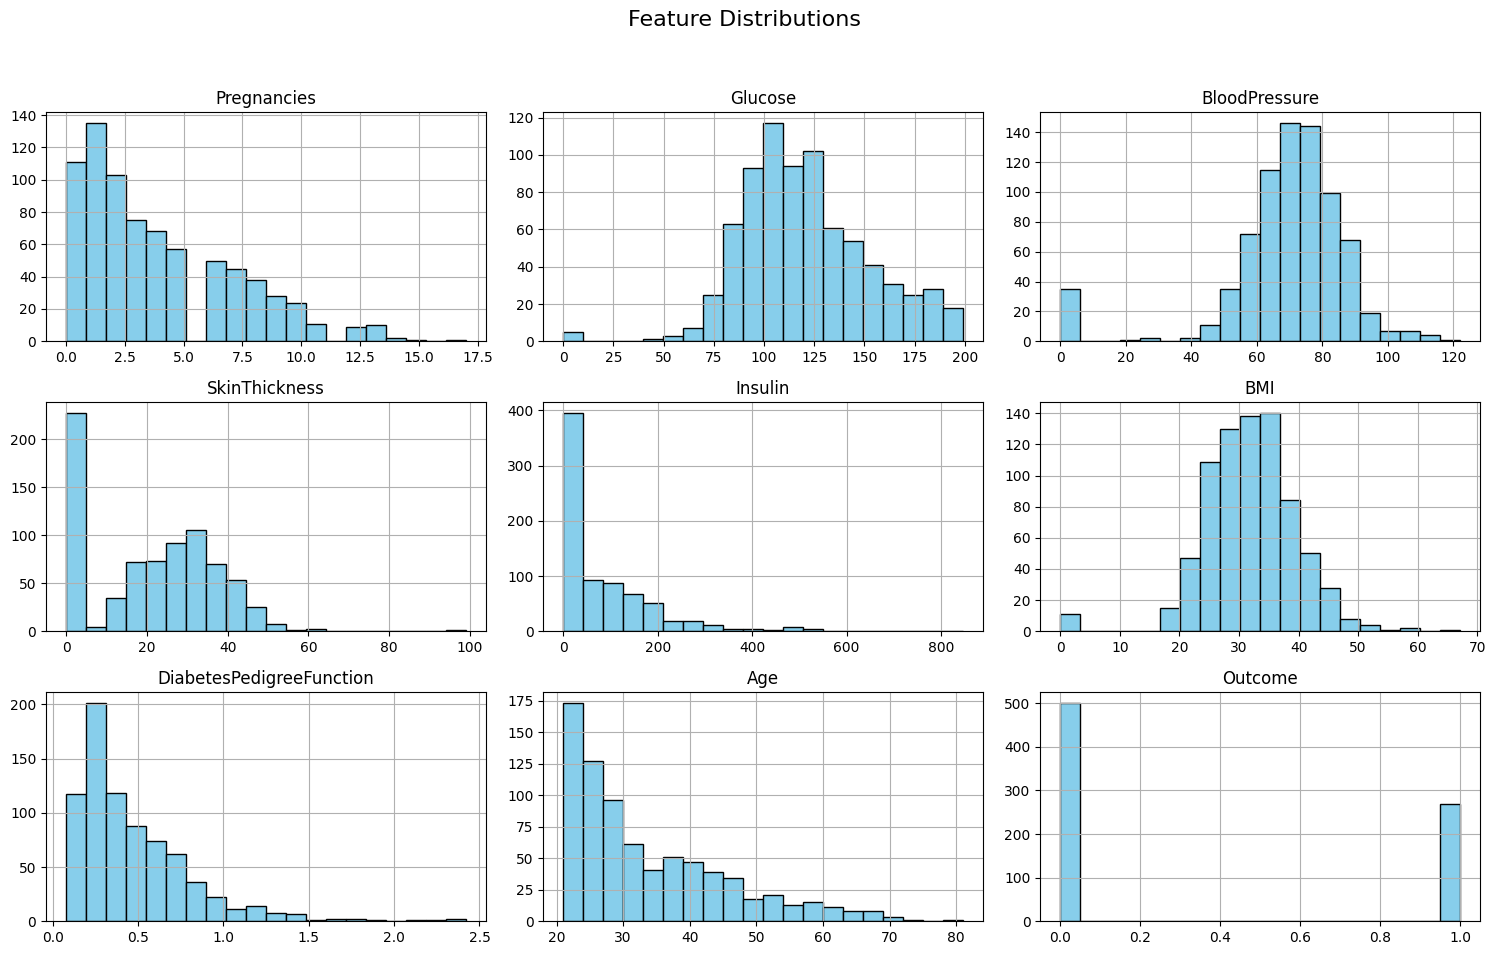

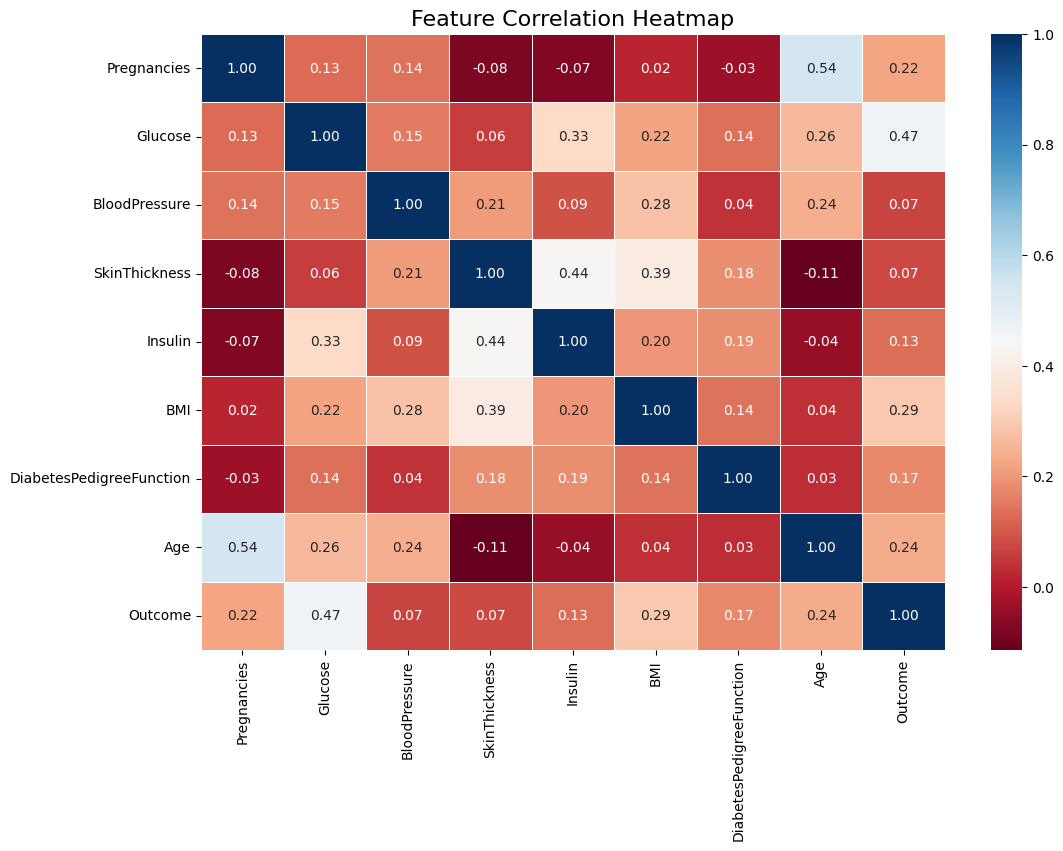

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualize distributions of each feature
df.hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 2. Calculate correlation matrix and visualize with a heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

## Data Preprocessing

### Subtask:
Handle missing values (zeros), scale features, and split the dataset into training and testing sets.


In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Handle missing values (zeros) in biologically invalid columns
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
# Replace 0 with NaN to use fillna efficiently
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
# Fill NaN with the median of each column
df[cols_with_zeros] = df[cols_with_zeros].fillna(df[cols_with_zeros].median())

print("Missing values handled. Zeros in invalid columns replaced with medians.")

# 2. Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 3. Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Normalize the feature variables
scaler = StandardScaler()
# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data Split and Scaled Successfully.")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Missing values handled. Zeros in invalid columns replaced with medians.
Data Split and Scaled Successfully.
Training set shape: (614, 8)
Testing set shape: (154, 8)


## Model Training and Evaluation

### Subtask:
Train a Random Forest classifier on the scaled training data and evaluate its performance using a confusion matrix and classification metrics.


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.72      0.61      0.66        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



<Figure size 800x600 with 0 Axes>

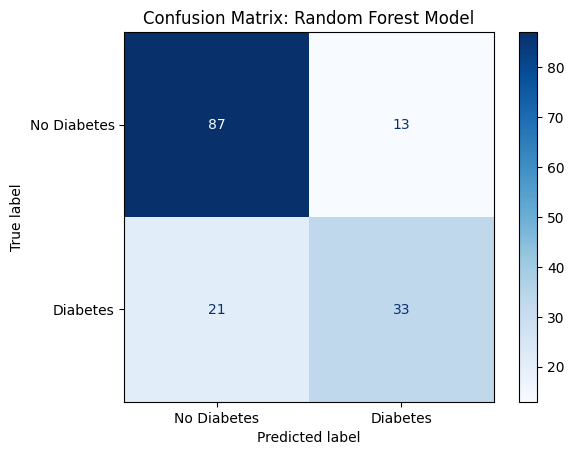

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Instantiate and fit the RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 2. Make predictions on the scaled test set
y_pred = rf_model.predict(X_test_scaled)

# 3. Print classification report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 4. Generate and display confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', display_labels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix: Random Forest Model')
plt.show()

## Feature Importance Visualization

### Subtask:
Visualize the importance of each feature in the Random Forest model to identify the key predictors of diabetes.


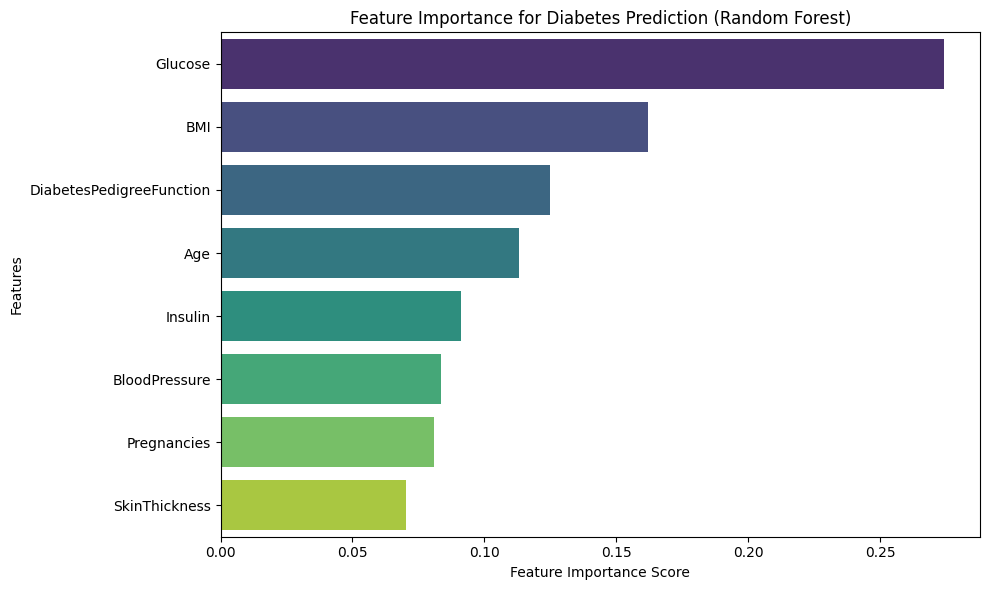

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract feature importance scores from the trained model
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# 3. Sort the features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# 4. Create the horizontal bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df, hue="Feature", palette="viridis", legend=False)

# 5. Add labels and title
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance for Diabetes Prediction (Random Forest)")

# 6. Display the plot
plt.tight_layout()
plt.show()

## Summary:

### Q&A

**What was the primary goal of this analysis?**
The goal was to build and evaluate a machine learning pipeline to predict diabetes using the Kaggle "diabetes-dataset." This involved exploratory data analysis (EDA), data cleaning, feature scaling, training a Random Forest classifier, and identifying key predictors of the disease.

**How did the model perform in predicting diabetes?**
The Random Forest classifier achieved an overall accuracy of **78%**. While it performed well in identifying non-diabetic cases (Recall: 0.87), it was more conservative in identifying diabetic cases (Recall: 0.61).

**Which factors were the most significant predictors of diabetes?**
Based on the feature importance analysis, **Glucose** and **BMI** were identified as the most influential features in the model's decision-making process.

### Data Analysis Key Findings

*   **Data Quality Issues:** Initial analysis revealed that while there were no explicit null values, several columns (Glucose, BloodPressure, SkinThickness, Insulin, and BMI) contained **invalid zeros**. These were successfully treated by replacing them with the median values of their respective columns.
*   **Feature Correlations:** Glucose showed the strongest positive correlation with the target variable (`Outcome`), which was later confirmed by the feature importance plot.
*   **Model Accuracy:** The Random Forest model reached an **accuracy of 78%** on the test set (154 samples).
*   **Class Imbalance Impact:** The model showed higher precision and recall for the "No Diabetes" class (0.81/0.87) compared to the "Diabetes" class (0.72/0.61), indicating it is more effective at ruling out diabetes than confirming it.
*   **Predictive Power:** The feature importance visualization established a clear hierarchy, with **Glucose** and **BMI** ranking at the top, followed by **Age** and **DiabetesPedigreeFunction**.

### Insights or Next Steps

*   **Address Class Imbalance:** Since the recall for diabetic cases (61%) is significantly lower than for non-diabetic cases, future iterations should explore techniques like SMOTE (Synthetic Minority Over-sampling Technique) or adjusting class weights to improve the detection of positive cases.
*   **Hyperparameter Tuning:** The current model uses default parameters; implementing a grid search or random search for the Random Forest model could potentially boost the overall accuracy and F1-score.
